In [1]:
import scanpy as sc

print("Scanpy imported successfully")
print(sc.AnnData)

Scanpy imported successfully
<class 'anndata._core.anndata.AnnData'>


In [2]:
data_path = "../data/GSE201348/GSM606145/"

adata = sc.read_10x_mtx(
    data_path,
    var_names="gene_symbols",
    make_unique=True
)

print(adata)

AnnData object with n_obs × n_vars = 1651 × 33538
    var: 'gene_ids', 'feature_types'


In [6]:
adata.obs.head()

""
AAACCCAAGTTATGGA-1
AAACCCACAACGCCCA-1
AAACCCAGTCAGTCCG-1
AAACGAAGTTGGTGTT-1
AAACGCTAGGAGCAAA-1


In [7]:
print(adata.obs.index[:5])

Index(['AAACCCAAGTTATGGA-1', 'AAACCCACAACGCCCA-1', 'AAACCCAGTCAGTCCG-1',
       'AAACGAAGTTGGTGTT-1', 'AAACGCTAGGAGCAAA-1'],
      dtype='object')


In [8]:
print(adata.obs.columns)

Index([], dtype='object')


In [10]:
adata.var.head()

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression


In [11]:
print(adata.X.shape)

(1651, 33538)


In [12]:
print(type(adata.X))

<class 'scipy.sparse._csc.csc_matrix'>


In [3]:
adata.obs["sample_id"] = "A001-C-007"
adata.obs["donor_id"] = "A001"
adata.obs["gross_pathology"] = "Adenocarcinoma"
adata.obs["donor_disease_status"] = "FAP"
adata.obs["condition"] = "CRC"

In [4]:
adata.obs.head()

,sample_id,donor_id,gross_pathology,donor_disease_status,condition
AAACCCAAGTTATGGA-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC
AAACCCACAACGCCCA-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC
AAACCCAGTCAGTCCG-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC
AAACGAAGTTGGTGTT-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC
AAACGCTAGGAGCAAA-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC


In [5]:
print(adata.obs.shape)
print(adata.obs["sample_id"].unique())
print(adata.obs["donor_id"].unique())
print(adata.obs["condition"].unique())

(1651, 5)
['A001-C-007']
['A001']
['CRC']


In [6]:
print(adata)

AnnData object with n_obs × n_vars = 1651 × 33538
    obs: 'sample_id', 'donor_id', 'gross_pathology', 'donor_disease_status', 'condition'
    var: 'gene_ids', 'feature_types'


In [7]:
sc.pp.calculate_qc_metrics(
    adata,
    percent_top=None,
    inplace=True
)

In [8]:
adata.obs.head()

,sample_id,donor_id,gross_pathology,donor_disease_status,condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts
AAACCCAAGTTATGGA-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC,1413,7.254178,1897.0,7.548556
AAACCCACAACGCCCA-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC,611,6.416732,770.0,6.647688
AAACCCAGTCAGTCCG-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC,503,6.222576,567.0,6.342122
AAACGAAGTTGGTGTT-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC,699,6.551080,860.0,6.758094
AAACGCTAGGAGCAAA-1,A001-C-007,A001,Adenocarcinoma,FAP,CRC,551,6.313548,642.0,6.466145


In [9]:
adata.obs[
    ["n_genes_by_counts", "total_counts"]
].describe()

,n_genes_by_counts,total_counts
count,1651.000000,1651.000000
mean,1340.358571,2737.249512
std,1325.481317,7005.233398
min,230.000000,500.000000
25%,619.000000,766.000000
50%,908.000000,1190.000000
75%,1494.500000,2161.000000
max,11554.000000,140348.000000


<function matplotlib.pyplot.show(close=None, block=None)>

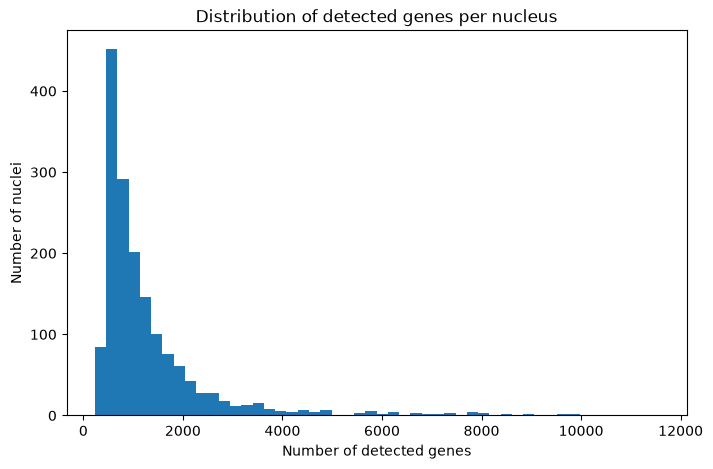

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    adata.obs["n_genes_by_counts"],
    bins=50
)

plt.xlabel("Number of detected genes")
plt.ylabel("Number of nuclei")
plt.title("Distribution of detected genes per nucleus")

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

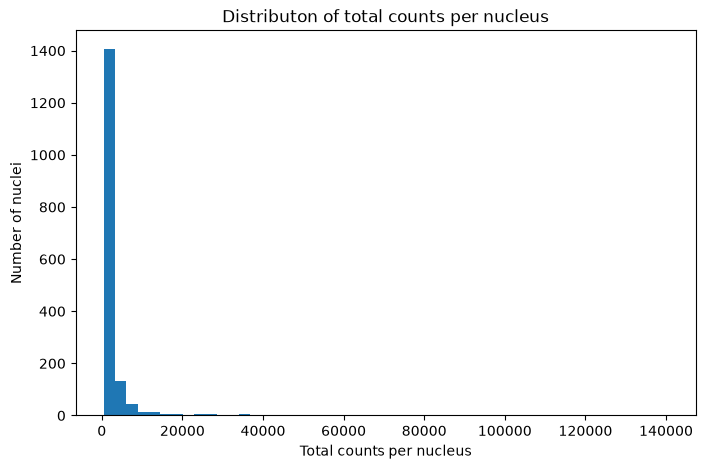

In [11]:
plt.figure(figsize=(8,5))

plt.hist(
    adata.obs["total_counts"],
    bins=50
)

plt.xlabel("Total counts per nucleus")
plt.ylabel("Number of nuclei")
plt.title("Distributon of total counts per nucleus")

plt.show